# 2. Exploratory Analysis: Global Tech Salaries

This notebook explores salary patterns in the cleaned global technology dataset.
We will compare roles, experience levels, continents, remote-work arrangements, and years.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

DATA_PATH = Path("../data/ds_salaries_clean.csv")
df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Rows: 565
Columns: 18


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_name,employment_name,remote_name,salary_log_usd,tunisian_record,employee_continent,company_continent
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L,Mid-level,Full-time,On-site,11.29,False,Europe,Europe
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S,Senior-level,Full-time,On-site,12.47,False,Asia,Asia
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M,Senior-level,Full-time,Hybrid,11.60,False,Europe,Europe
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S,Mid-level,Full-time,On-site,9.90,False,North America,North America
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L,Senior-level,Full-time,Hybrid,11.92,False,North America,North America


## Dataset overview

Before interpreting patterns, check the time range, salary scale, job titles, and geographic coverage.

In [2]:
overview = pd.Series({
    "rows": len(df),
    "unique_job_titles": df["job_title"].nunique(),
    "unique_employee_countries": df["employee_residence"].nunique(),
    "unique_company_countries": df["company_location"].nunique(),
    "year_min": df["work_year"].min(),
    "year_max": df["work_year"].max(),
    "median_salary_usd": df["salary_in_usd"].median(),
    "mean_salary_usd": df["salary_in_usd"].mean(),
})
display(overview.to_frame("value"))

print("Salary percentiles:")
display(df["salary_in_usd"].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).to_frame())

,value
rows,565.00
unique_job_titles,50.00
unique_employee_countries,57.00
unique_company_countries,50.00
year_min,2020.00
year_max,2022.00
median_salary_usd,100000.00
mean_salary_usd,110610.34


Salary percentiles:


,salary_in_usd
count,565.00
mean,110610.34
std,72280.70
min,2859.00
25%,60757.00
50%,100000.00
75%,150000.00
90%,200000.00
max,600000.00


## Salary by experience level

Median salary is more robust than mean salary when a dataset contains very high executive salaries. We show both the number of records and the median.

In [3]:
experience_order = ["Entry-level", "Mid-level", "Senior-level", "Executive", "Other"]

experience_summary = (
    df.groupby("experience_name", observed=True)["salary_in_usd"]
    .agg(job_count="count", median_salary_usd="median", mean_salary_usd="mean")
    .reindex(experience_order)
    .dropna(how="all")
 )

display(experience_summary)

,job_count,median_salary_usd,mean_salary_usd
experience_name,,,
Entry-level,88.00,56500.00,61643.32
Mid-level,208.00,76940.00,87793.00
Senior-level,243.00,135000.00,138374.88
Executive,26.00,171437.50,199392.04


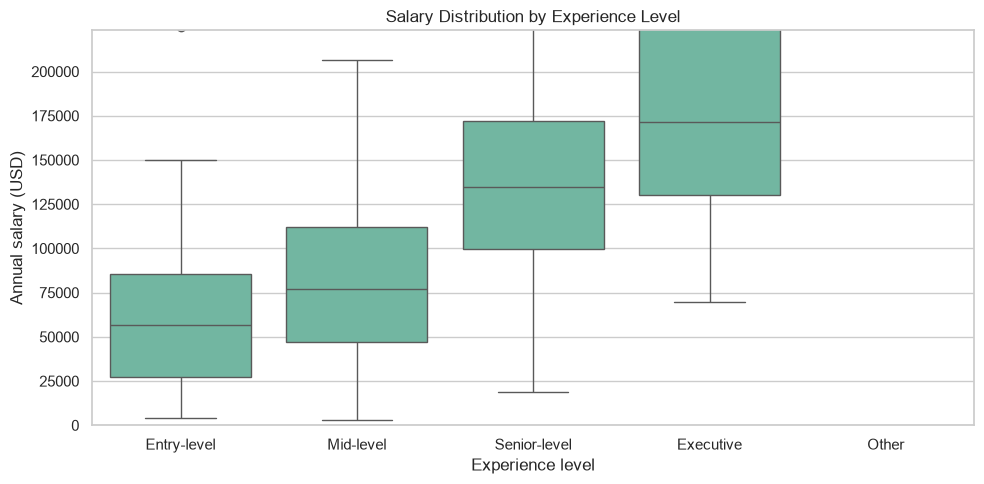

In [4]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x="experience_name",
    y="salary_in_usd",
    order=experience_order,
 )
plt.ylim(0, df["salary_in_usd"].quantile(0.95))
plt.title("Salary Distribution by Experience Level")
plt.xlabel("Experience level")
plt.ylabel("Annual salary (USD)")
plt.tight_layout()
plt.show()

## Job-title demand and salary

Rare job titles can produce misleading salary averages, so the salary table below includes only titles with at least five observations.

In [5]:
title_summary = (
    df.groupby("job_title")["salary_in_usd"]
    .agg(job_count="count", median_salary_usd="median")
    .sort_values(["job_count", "median_salary_usd"], ascending=[False, False])
 )

print("Most common job titles:")
display(title_summary.head(15))

common_titles = title_summary[title_summary["job_count"] >= 5]
print("Median salary for job titles with at least five records:")
display(common_titles.sort_values("median_salary_usd", ascending=False).head(15))

Most common job titles:


,job_count,median_salary_usd
job_title,,
Data Scientist,130,100000.00
Data Engineer,121,100800.00
Data Analyst,82,90000.00
Machine Learning Engineer,39,87425.00
Research Scientist,16,76263.50
Data Science Manager,12,155750.00
Data Architect,11,180000.00
Machine Learning Scientist,8,156500.00
Big Data Engineer,8,41305.50


Median salary for job titles with at least five records:


,job_count,median_salary_usd
job_title,,
Head of Data,5,200000.00
Data Architect,11,180000.00
Principal Data Scientist,7,173762.00
Director of Data Science,7,168000.00
Applied Data Scientist,5,157000.00
Machine Learning Scientist,8,156500.00
Data Science Manager,12,155750.00
Data Engineering Manager,5,150000.00
Lead Data Engineer,6,121593.50


In [6]:
continent_summary = (
    df.groupby("company_continent", observed=True)["salary_in_usd"]
    .agg(job_count="count", median_salary_usd="median", mean_salary_usd="mean")
    .sort_values("median_salary_usd", ascending=False)
 )

remote_summary = (
    df.groupby("remote_name", observed=True)["salary_in_usd"]
    .agg(job_count="count", median_salary_usd="median", mean_salary_usd="mean")
    .sort_values("median_salary_usd", ascending=False)
 )

print("Salary by company continent:")
display(continent_summary)
print("Salary by remote-work arrangement:")
display(remote_summary)

Salary by company continent:


,job_count,median_salary_usd,mean_salary_usd
company_continent,,,
North America,350,130000.00,139442.73
Oceania,4,106212.50,112282.00
Europe,150,63831.00,69887.23
Asia,44,31021.50,50236.59
Africa,4,30000.00,42318.00
South America,5,21844.00,23538.00
Other,8,19112.00,32538.25


Salary by remote-work arrangement:


,job_count,median_salary_usd,mean_salary_usd
remote_name,,,
Fully remote,346,110712.50,120763.19
On-site,121,98158.00,105785.40
Hybrid,98,68010.50,80721.90


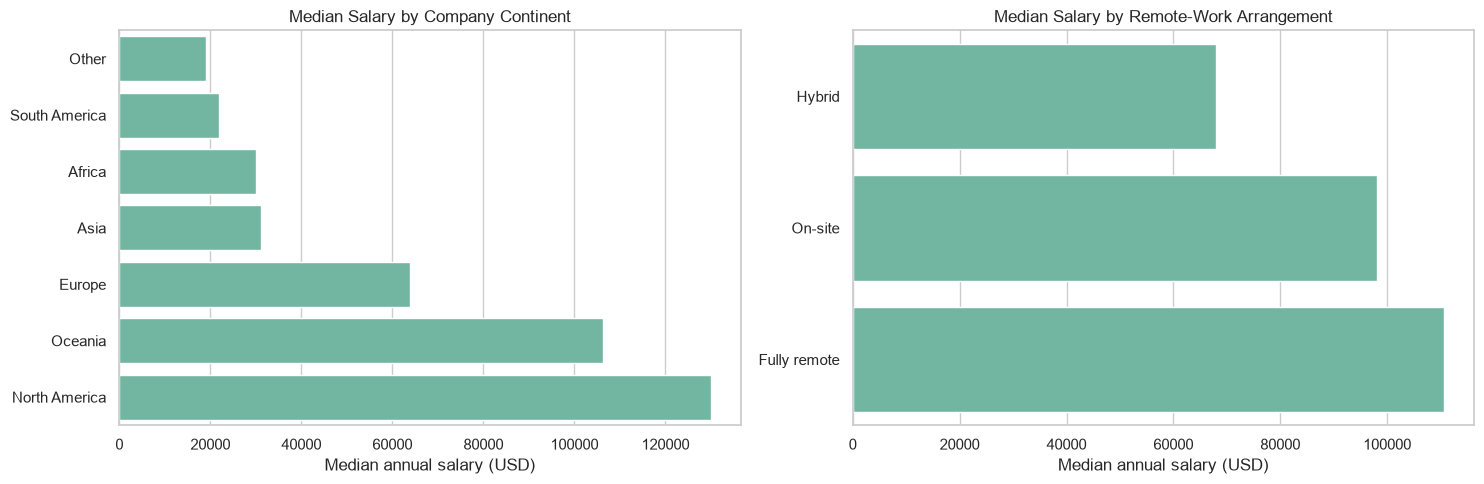

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

continent_plot = continent_summary.sort_values("median_salary_usd")
sns.barplot(
    data=continent_plot.reset_index(),
    x="median_salary_usd",
    y="company_continent",
    ax=axes[0],
 )
axes[0].set_title("Median Salary by Company Continent")
axes[0].set_xlabel("Median annual salary (USD)")
axes[0].set_ylabel("")

remote_plot = remote_summary.sort_values("median_salary_usd")
sns.barplot(
    data=remote_plot.reset_index(),
    x="median_salary_usd",
    y="remote_name",
    ax=axes[1],
 )
axes[1].set_title("Median Salary by Remote-Work Arrangement")
axes[1].set_xlabel("Median annual salary (USD)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## Salary trends over time

The dataset covers 2020 to 2022. We compare yearly medians while showing the number of records behind each estimate.

,work_year,job_count,median_salary_usd,mean_salary_usd
0,2020,72,75544.00,95813.00
1,2021,215,82528.00,99430.41
2,2022,278,120000.00,123089.10


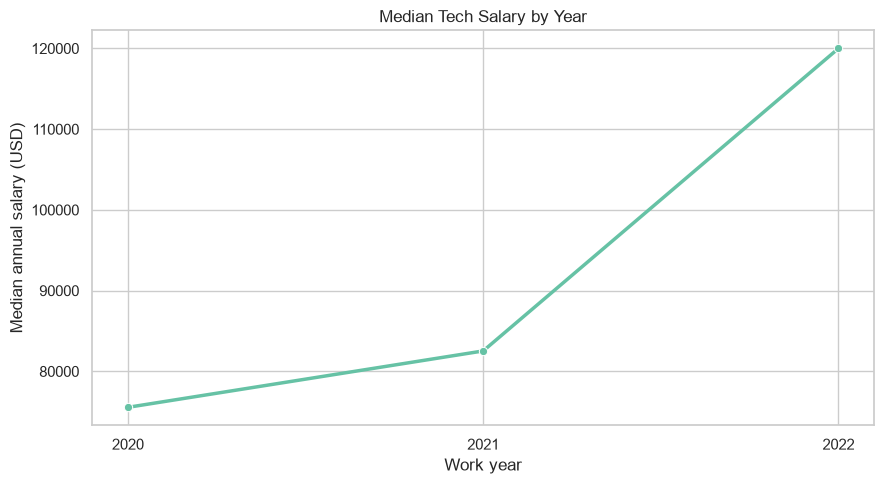

In [8]:
year_summary = (
    df.groupby("work_year")["salary_in_usd"]
    .agg(job_count="count", median_salary_usd="median", mean_salary_usd="mean")
    .reset_index()
 )

display(year_summary)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=year_summary,
    x="work_year",
    y="median_salary_usd",
    marker="o",
    linewidth=2.5,
 )
plt.title("Median Tech Salary by Year")
plt.xlabel("Work year")
plt.ylabel("Median annual salary (USD)")
plt.xticks(year_summary["work_year"].tolist())
plt.tight_layout()
plt.show()

## Interpretation checklist

Use these outputs to discuss:

- Whether seniority is associated with higher pay.
- Which job titles are both common and well-paid.
- Whether geographic differences may reflect sample composition rather than causal effects.
- Whether remote-work salary differences remain after controlling for experience and role.
- Why the single Tunisia-related record is insufficient for a Tunisia-specific conclusion.